# Reward hacking in Metaworld CEM planning — visualized

**What this notebook shows.** In our latent-oracle pipeline the CEM planner minimizes a
*cost* defined in the world model's latent space. Reward hacking = the planner drives its
own cost **down** while the **true** object / gripper position stays **wrong** — it exploits
residual-error pockets of the cost instead of solving the task.

**Data provenance.** Every row is a CEM *elite* (a candidate action plan the planner kept)
mined by `scripts/35_cem_exploit_precision.py` over real Metaworld episodes
(`dino_wm_metaworld`, tasks `mw-push` + `mw-pick-place`, 16 episodes each, 6 CEM
iterations). For each elite the mining code (`scripts/_cem_mining.py` →
`scripts/30_latent_oracle.cem_plan_latent`) rolls the **real MuJoCo simulator** forward with
that plan, so:

- `cost`      — what the planner *believed* (low = "near goal"). **This is what CEM minimizes.**
- `obj`,`ee`  — the **true** object / end-effector position that plan actually produces.
- `goal_obj`  — the true goal object position.
- `it`        — CEM iteration 0..5 (the search converges as `it` grows).

So `true_gap = ‖obj − goal_obj‖` is *reality*, and the gap between `cost↓` and `true_gap`
staying flat **is** the reward hacking.

> Runs on CPU from `results/cem_exploit_lite.npz` (a 232 KB extract of the 10 GB buffer
> `results/cem_exploit_buffer_round0.pt`). Section 6 shows real RGB frames if you regenerate
> the buffer with `--keep-frames` on the GPU cluster (see the Appendix).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent  # allow running from diagnosis/ or diagnosis/notebooks/
LITE = ROOT / "results" / "cem_exploit_lite.npz"

d = np.load(LITE, allow_pickle=True)
cost      = d["cost"]                    # (N,) planner belief (minimized)
obj       = d["obj"]                     # (N,3) TRUE object pos
ee        = d["ee"]                      # (N,3) TRUE end-effector pos
goal_obj  = d["goal_obj"]                # (N,3) goal object pos
task      = d["task"].astype(str)        # (N,) 'mw-push' | 'mw-pick-place'
it        = d["it"]                      # (N,) CEM iteration 0..5
seed      = d["seed"]                    # (N,) episode seed

true_gap  = np.linalg.norm(obj - goal_obj, axis=1)   # (N,) TRUE object->goal distance (m)
IT_MAX    = int(it.max())
PUSH_R, PICK_R = 0.05, 0.07              # Metaworld success radii (m)
TASKS = ["mw-push", "mw-pick-place"]
COL = {"mw-push": "#2f6db3", "mw-pick-place": "#b5482f"}

print(f"{len(cost):,} CEM elites | tasks={sorted(set(task))} | CEM iters 0..{IT_MAX}")
print(f"true object->goal gap: median {100*np.median(true_gap):.1f} cm, "
      f"min {100*true_gap.min():.1f} cm, max {100*true_gap.max():.1f} cm")

13,440 CEM elites | tasks=[np.str_('mw-pick-place'), np.str_('mw-push')] | CEM iters 0..5
true object->goal gap: median 24.9 cm, min 0.4 cm, max 34.2 cm


## 1. The money plot — cost falls, reality doesn't move

Across CEM iterations the planner's cost drops monotonically (it *thinks* it is getting
closer to the goal). But the **true** object→goal distance is flat. The planner is
optimizing its own metric into a residual-error pocket, not moving the object.

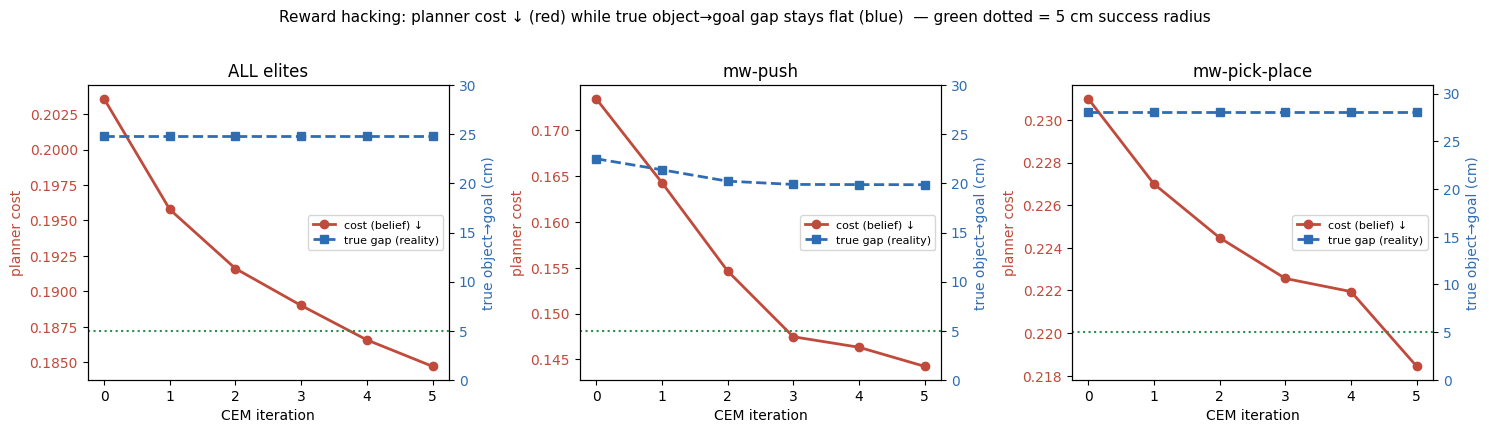

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

def panel(ax, mask, title):
    its = np.arange(IT_MAX + 1)
    cost_med = [np.median(cost[mask & (it == i)]) for i in its]
    gap_med  = [100*np.median(true_gap[mask & (it == i)]) for i in its]
    l1, = ax.plot(its, cost_med, "o-", color="#c04a3b", lw=2, label="planner cost (belief) ↓")
    ax.set_xlabel("CEM iteration"); ax.set_ylabel("planner cost", color="#c04a3b")
    ax.tick_params(axis="y", labelcolor="#c04a3b")
    ax2 = ax.twinx()
    l2, = ax2.plot(its, gap_med, "s--", color="#2f6db3", lw=2, label="TRUE obj→goal (cm)")
    ax2.axhline(100*PUSH_R, color="#2a8f4e", ls=":", lw=1.5)
    ax2.set_ylabel("true object→goal (cm)", color="#2f6db3")
    ax2.tick_params(axis="y", labelcolor="#2f6db3")
    ax2.set_ylim(0, max(30, 1.1*max(gap_med)))
    ax.set_title(title)
    ax.legend([l1, l2], ["cost (belief) ↓", "true gap (reality)"], loc="center right", fontsize=8)

panel(axes[0], np.ones_like(it, bool), "ALL elites")
panel(axes[1], task == "mw-push", "mw-push")
panel(axes[2], task == "mw-pick-place", "mw-pick-place")
fig.suptitle("Reward hacking: planner cost ↓ (red) while true object→goal gap stays flat (blue)  "
             "— green dotted = 5 cm success radius", y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

**Read-out.** The red curve (what CEM optimizes) slides down every iteration. The blue
curve (where the object actually is) barely moves and sits far above the 5 cm success line.
For `mw-pick-place` the true gap is *perfectly flat* — the arm never even establishes a
grasp, so the object is literally stationary while the planner keeps "improving" its cost.

## 2. The cost cannot tell success from failure

Each point is a converged (final-iteration) elite: x = the cost CEM assigned, y = the true
object→goal distance. A faithful cost would put every low-cost plan *below* its success line.
Instead the low-cost region is full of failures — CEM keeps a whole population of plans it
scores as near-minimal cost, but only a tiny fraction actually reach the goal.

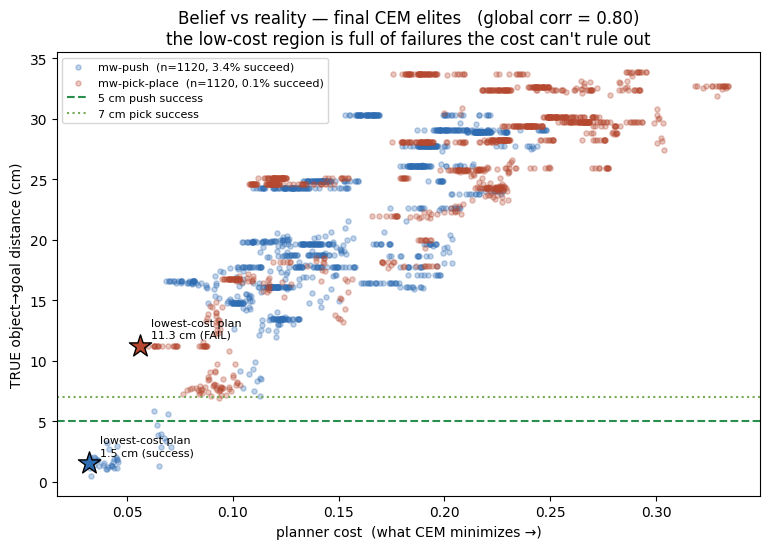

Can the cost separate genuine successes from failures? (final elites)
  mw-push:
    overall   3.4% of 'elite' plans succeed (<5 cm)
    lowest-cost 10% of plans:   33.9% succeed, median gap 14.8 cm
    min cost among successes = 0.0319 | among failures(>2R) = 0.0684  (overlapping)
  mw-pick-place:
    overall   0.1% of 'elite' plans succeed (<7 cm)
    lowest-cost 10% of plans:    0.9% succeed, median gap 11.3 cm
    min cost among successes = 0.0935 | among failures(>2R) = 0.0890  (INVERTED — cost prefers a failure!)


In [3]:
mf = it == IT_MAX
R = {"mw-push": PUSH_R, "mw-pick-place": PICK_R}
fig, ax = plt.subplots(figsize=(7.8, 5.6))
for t in TASKS:
    m = mf & (task == t)
    ax.scatter(cost[m], 100*true_gap[m], s=14, alpha=0.30, color=COL[t],
               label=f"{t}  (n={m.sum()}, {100*(true_gap[m]<R[t]).mean():.1f}% succeed)")
    # lowest-cost plan the planner would actually commit to
    j = np.where(m)[0][np.argmin(cost[m])]
    ok = true_gap[j] < R[t]
    ax.scatter(cost[j], 100*true_gap[j], s=280, marker="*", edgecolor="k",
               facecolor=COL[t], zorder=5)
    ax.annotate(f"lowest-cost plan\n{100*true_gap[j]:.1f} cm ({'success' if ok else 'FAIL'})",
                (cost[j], 100*true_gap[j]), textcoords="offset points", xytext=(8, 6), fontsize=8)
ax.axhline(100*PUSH_R, color="#2a8f4e", ls="--", lw=1.5, label="5 cm push success")
ax.axhline(100*PICK_R, color="#7a5", ls=":",  lw=1.5, label="7 cm pick success")
ax.set_xlabel("planner cost  (what CEM minimizes →)")
ax.set_ylabel("TRUE object→goal distance (cm)")
r = np.corrcoef(cost[mf], true_gap[mf])[0, 1]
ax.set_title(f"Belief vs reality — final CEM elites   (global corr = {r:.2f})\n"
             f"the low-cost region is full of failures the cost can't rule out")
ax.legend(fontsize=8, loc="upper left"); plt.tight_layout(); plt.show()

print("Can the cost separate genuine successes from failures? (final elites)")
for t in TASKS:
    m = mf & (task == t); c, g = cost[m], true_gap[m]
    lowdec = c <= np.quantile(c, 0.10)
    succ, fail = g < R[t], g > 2*R[t]
    print(f"  {t}:")
    print(f"    overall {100*succ.mean():5.1f}% of 'elite' plans succeed (<{100*R[t]:.0f} cm)")
    print(f"    lowest-cost 10% of plans:  {100*(g[lowdec]<R[t]).mean():5.1f}% succeed, median gap {100*np.median(g[lowdec]):.1f} cm")
    if succ.any() and fail.any():
        inv = "INVERTED — cost prefers a failure!" if c[fail].min() < c[succ].min() else "overlapping"
        print(f"    min cost among successes = {c[succ].min():.4f} | among failures(>2R) = {c[fail].min():.4f}  ({inv})")

**Read-out.** Cost and truth are only *weakly* correlated (~0.8) — the cost is not
random noise. Reward hacking is subtler than that: CEM drives into the **low-cost tail**, and
exactly there the cost stops discriminating. For `mw-push` only ~3% of the plans the cost
calls "elite" actually succeed. For `mw-pick-place` it is worse than useless — the tail is
**inverted**: the lowest-cost plan is itself a failure and undercuts the best genuine success,
so CEM (a *minimizer*) actively prefers the failing plan. Minimizing this cost selects wrong
plans — that is the hack.

## 3. Where the object actually ends up (top-down map)

Top-down (x–y) view of one episode. Green ✚ = goal. Coloured dots = the true object position
of every elite the planner kept; ★ = its most-confident plan. The cloud clusters far from the
goal — the planner's cost is minimized in a region where the object simply isn't.

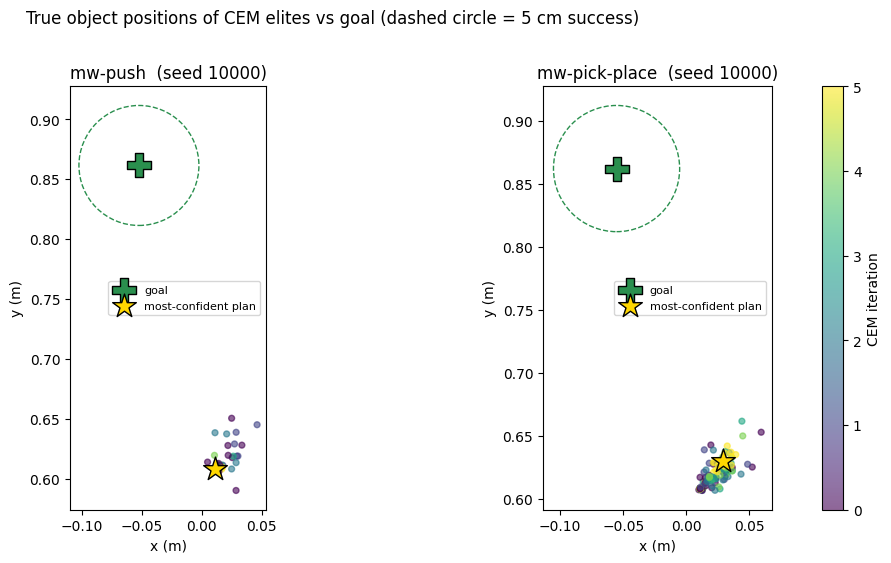

In [4]:
def spatial(t, ax):
    m = (task == t)
    seeds = sorted(set(seed[m]))
    s0 = seeds[0]
    ms = m & (seed == s0)
    g = goal_obj[ms][0]
    sc = ax.scatter(obj[ms, 0], obj[ms, 1], c=it[ms], cmap="viridis", s=18, alpha=0.6)
    ax.scatter(*g[:2], marker="P", s=320, color="#2a8f4e", edgecolor="k", zorder=6, label="goal")
    mf_s = ms & (it == IT_MAX)
    j = np.where(mf_s)[0][np.argmin(cost[mf_s])]
    ax.scatter(obj[j, 0], obj[j, 1], marker="*", s=320, facecolor="gold",
               edgecolor="k", zorder=7, label="most-confident plan")
    ax.add_patch(plt.Circle(g[:2], PUSH_R, fill=False, ls="--", color="#2a8f4e"))
    ax.set_title(f"{t}  (seed {s0})"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    ax.set_aspect("equal"); ax.legend(fontsize=8)
    return sc

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sc = None
for ax, t in zip(axes, TASKS):
    sc = spatial(t, ax)
cb = fig.colorbar(sc, ax=axes, fraction=0.03); cb.set_label("CEM iteration")
fig.suptitle("True object positions of CEM elites vs goal (dashed circle = 5 cm success)", y=1.02)
plt.show()

## 4. How often does the planner's best plan actually succeed?

Distribution of the true object→goal gap over final-iteration elites, per task. The mass sits
well to the right of the success radii — the cost endorses a huge population of failing plans.

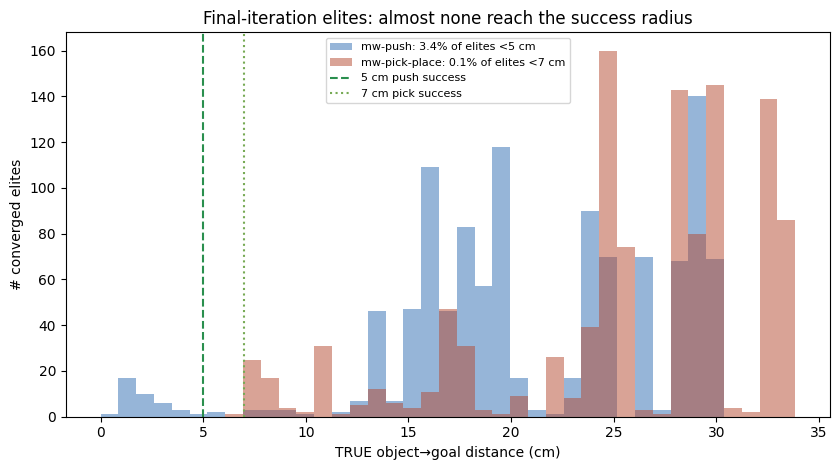

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
bins = np.linspace(0, 100*true_gap[mf].max(), 40)
R = {"mw-push": PUSH_R, "mw-pick-place": PICK_R}   # per-task success radius (bug fix:
                                                    # this used to always use PUSH_R)
for t in TASKS:
    m = mf & (task == t)
    frac = 100*(true_gap[m] < R[t]).mean()
    ax.hist(100*true_gap[m], bins=bins, alpha=0.5, color=COL[t],
            label=f"{t}: {frac:.1f}% of elites <{100*R[t]:.0f} cm")
ax.axvline(100*PUSH_R, color="#2a8f4e", ls="--", lw=1.5, label="5 cm push success")
ax.axvline(100*PICK_R, color="#7a5", ls=":",  lw=1.5, label="7 cm pick success")
ax.set_xlabel("TRUE object→goal distance (cm)"); ax.set_ylabel("# converged elites")
ax.set_title("Final-iteration elites: almost none reach the success radius")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 5. Why `reach` would look different (task-dependence)

Reward hacking is **not** a property of the planner alone — it is `f(planner strength) ×
(is the cost wrong along the task's path)`. Reaching moves only the gripper through smooth,
well-represented dynamics, so the cost surface is monotonic and CEM has no pocket to exploit
(`reach` closes 16/16 in our runs). `push`/`pick` force the system through the frozen
encoder's **contact blind spot**, where the latent cost is non-monotonic → CEM finds the
pockets shown above. This buffer only contains the two contact tasks; the clean `reach`
control lives in the planning-success tables (`results/`), not in this exploit buffer.

## 6. See it — real RGB frames (needs the frames buffer)

Coordinates are rigorous but abstract. This section loads a small buffer regenerated with
`--keep-frames` (Appendix) and makes the hack *visible* two ways. The problem with a naive
"goal vs plan" side-by-side is that the puck is a few pixels wide — so every RGB frame here is
paired with an **accurate top-down schematic drawn from the ground-truth 3-D coordinates**
(green ✚ = goal, dashed = success radius, red ● = object, blue ▲ = gripper). The schematic
never lies about where the object is.

In [6]:
import torch
FRAMES_BUF = ROOT / "results" / "cem_exploit_buffer_frames.pt"
if not FRAMES_BUF.exists():
    print("No frames buffer yet — run scripts/slurm_exploit_frames.sh on the cluster "
          "(see Appendix), then re-run this cell.")
    fb = None
else:
    fb = torch.load(FRAMES_BUF, map_location="cpu", weights_only=False)
    frames   = fb["frames"].numpy()            # (N,224,224,3) uint8
    fobj     = fb["obj"].numpy(); fgoal = fb["goal_obj"].numpy(); fee = fb["ee"].numpy()
    fcost    = np.asarray(fb["cost"]); fit = np.asarray(fb["iter"])
    ftask    = np.asarray(fb["task"]); fep = np.asarray(fb["ep_idx"])
    fgap     = np.linalg.norm(fobj - fgoal, axis=1)
    gframes  = fb["ep_goal_frames"].numpy()    # (n_ep,224,224,3)
    itmax    = int(fit.max())
    Rof      = {"mw-push": PUSH_R, "mw-pick-place": PICK_R}
    print(f"frames buffer: {len(frames)} elites, {len(gframes)} episodes")

def topdown(ax, ep_obj, goal, ees, R, mark_idx=None, colors=None):
    '''Top-down (x,y) schematic in cm, drawn from ground-truth coords.'''
    g = 100*goal
    ax.add_patch(plt.Circle((g[0], g[1]), 100*R, fill=False, ls="--", color="#2a8f4e", lw=1.5))
    ax.scatter(*g[:2], marker="P", s=240, color="#2a8f4e", edgecolor="k", zorder=6, label="goal")
    ax.scatter(100*ees[:, 0], 100*ees[:, 1], marker="^",
               s=60, facecolor="#2f6db3", edgecolor="k", alpha=0.7, zorder=4, label="gripper")
    ax.scatter(100*ep_obj[:, 0], 100*ep_obj[:, 1], marker="o", s=45, facecolor="#b5482f",
               edgecolor="k", alpha=0.8, zorder=5, label="object")
    ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)"); ax.set_aspect("equal")
    ax.legend(fontsize=7, loc="best")

frames buffer: 3360 elites, 8 episodes


### 6A. Same physical outcome, different cost — the cost isn't watching the object

One episode. CEM tries 70 action plans; the puck **does not move** (position std ≈ 0 cm). Yet
the world-model cost swings by ~40% and CEM commits to the lowest one. The four frames below
span that cost range low→high — the arm/gripper pose changes (that is what the cost is
tracking), but the object sits in the *same wrong place* in all four. Minimizing this cost
optimizes arm pose, not the task.

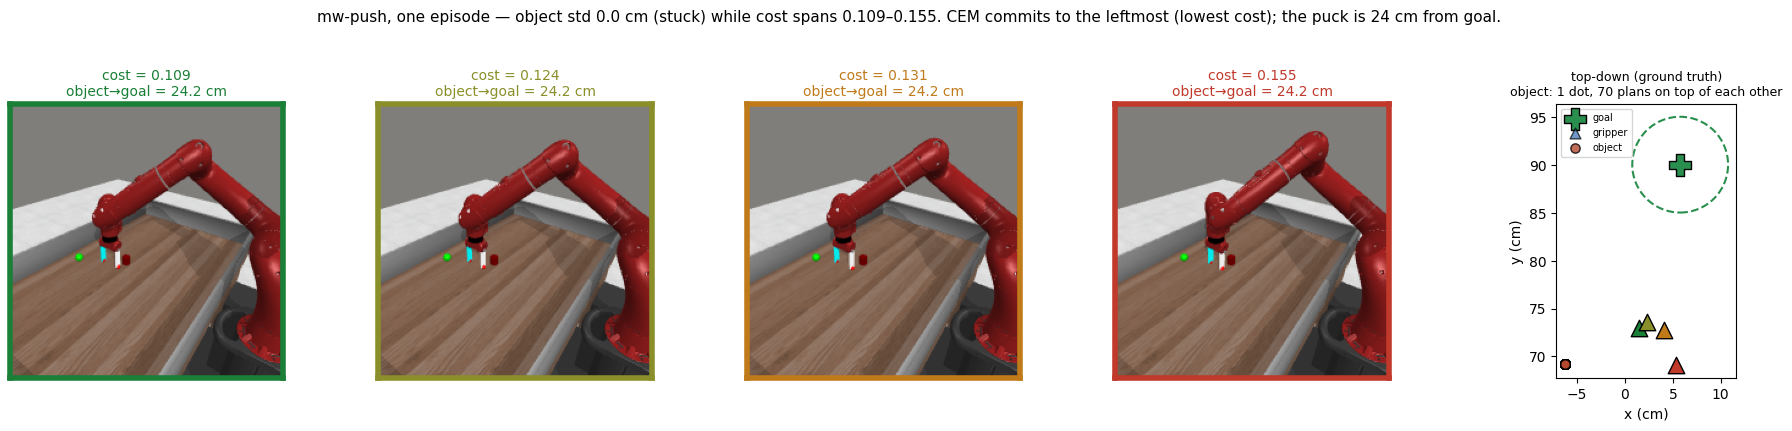

In [7]:
if fb is not None:
    # pick the episode whose object moves least while cost varies most (purest blindness).
    # Prefer mw-push: object stays on the table (z~0) so the top-down (x,y) distance equals
    # the true 3-D gap — no hidden lift for a viewer to distrust.
    cand = []
    for e in sorted(set(fep)):
        m = (fep == e) & (fit == itmax); o = fobj[m]
        move = float(np.linalg.norm(o - o.mean(0), axis=1).std())
        push_bonus = 1.0 if ftask[m][0] == "mw-push" else 0.0
        cand.append((push_bonus, fcost[m].max() - fcost[m].min() - 5*move, e))
    ep = max(cand)[2]
    m = np.where((fep == ep) & (fit == itmax))[0]
    order = m[np.argsort(fcost[m])]
    sel = order[np.linspace(0, len(order) - 1, 4).astype(int)]   # 4 elites spanning cost
    bc = ["#1a7f37", "#8a8f2a", "#c07a1a", "#c0392b"]            # low→high cost colour
    t = ftask[m][0]
    fig, axes = plt.subplots(1, 5, figsize=(19, 4.1),
                             gridspec_kw={"width_ratios": [1, 1, 1, 1, 1.15]})
    for k, j in enumerate(sel):
        axes[k].imshow(frames[j])
        axes[k].set_title(f"cost = {fcost[j]:.3f}\nobject→goal = {100*fgap[j]:.1f} cm",
                          fontsize=10, color=bc[k])
        axes[k].set_xticks([]); axes[k].set_yticks([])
        for s in axes[k].spines.values():
            s.set_color(bc[k]); s.set_linewidth(4)
    topdown(axes[4], fobj[m], fgoal[m][0], fee[sel], Rof[t])
    for k, j in enumerate(sel):   # recolour the 4 selected gripper markers to match frames
        axes[4].scatter(100*fee[j, 0], 100*fee[j, 1], marker="^", s=140,
                        facecolor=bc[k], edgecolor="k", zorder=7)
    axes[4].set_title("top-down (ground truth)\nobject: 1 dot, 70 plans on top of each other",
                      fontsize=9)
    om = fobj[m]
    fig.suptitle(f"{t}, one episode — object std {100*np.linalg.norm(om-om.mean(0),axis=1).std():.1f} cm "
                 f"(stuck) while cost spans {fcost[m].min():.3f}–{fcost[m].max():.3f}. "
                 f"CEM commits to the leftmost (lowest cost); the puck is {100*fgap[sel[0]]:.0f} cm from goal.",
                 fontsize=11, y=1.04)
    plt.tight_layout(); plt.show()

### 6B. Goal vs the committed plan, with a readable map

For several episodes: the **goal frame** the planner aimed at, the **plan it committed to**
(lowest cost), and the top-down schematic. The red object dot never lands inside the green
success circle — the plan CEM was most confident in leaves the object tens of cm away.

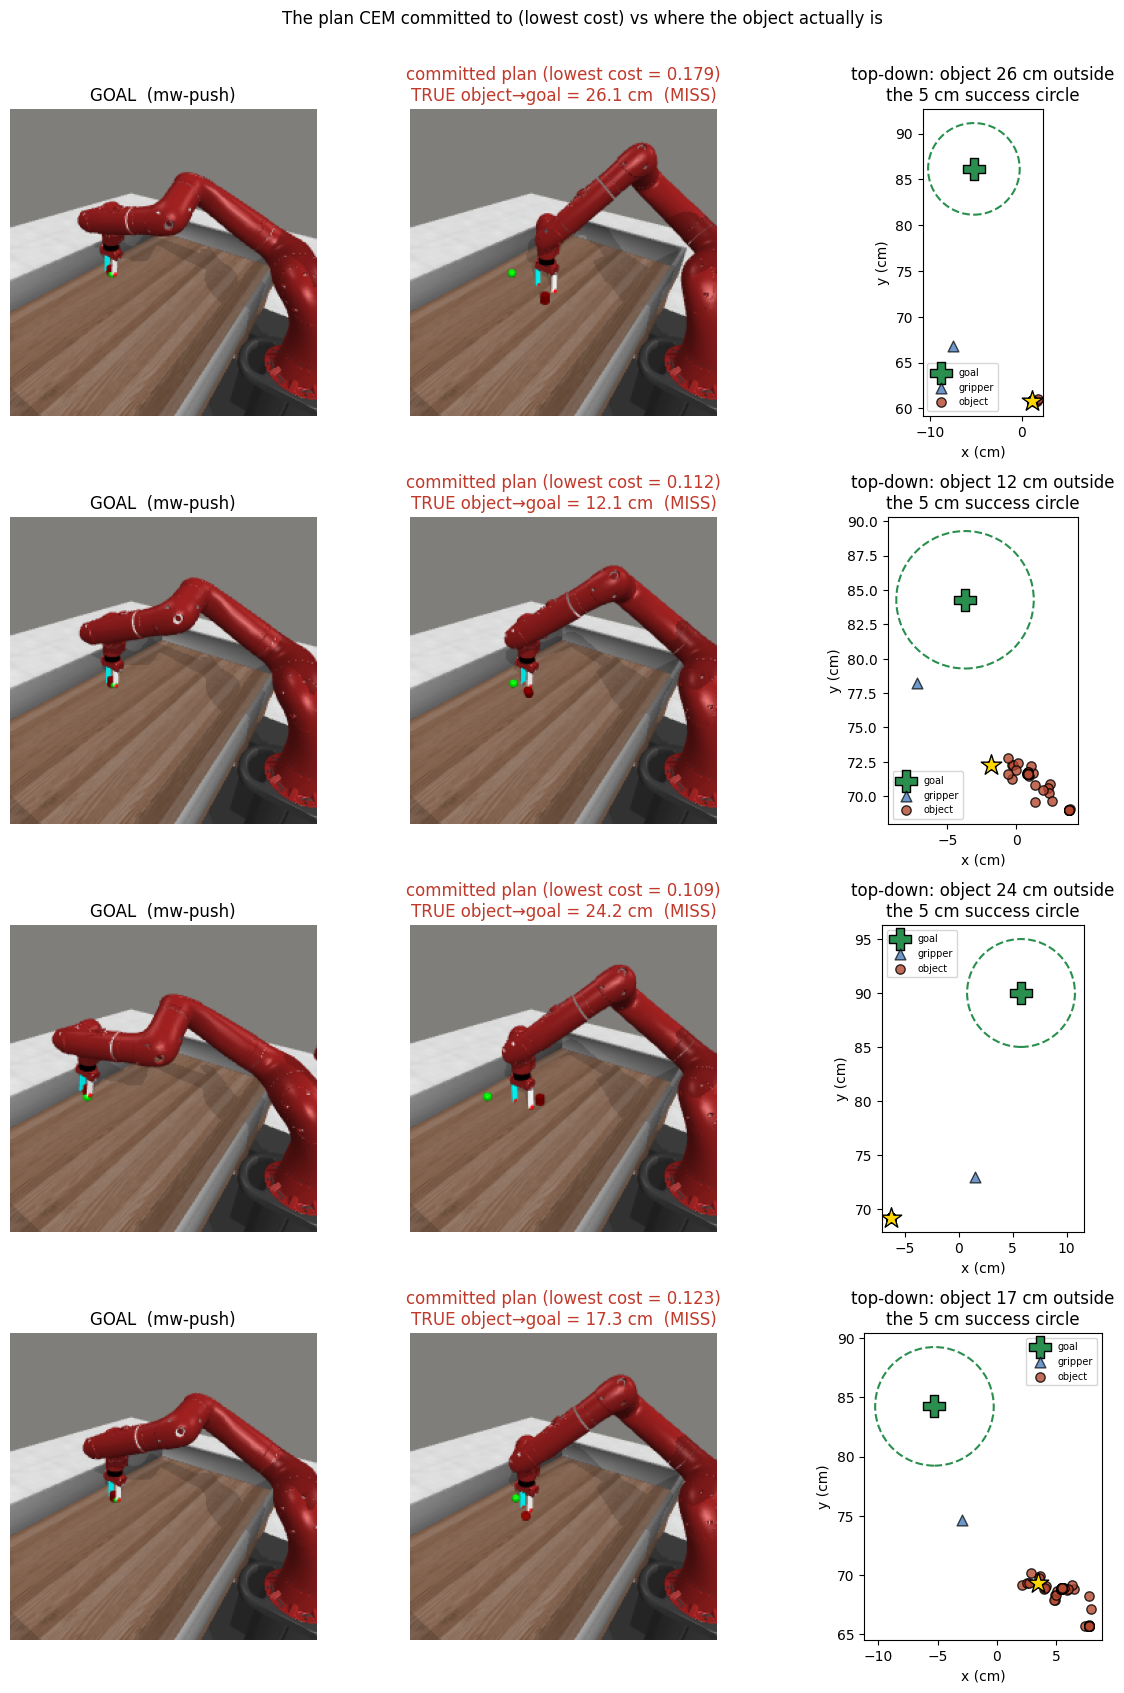

In [8]:
if fb is not None:
    eps = sorted(set(fep))[:4]
    fig, axes = plt.subplots(len(eps), 3, figsize=(12.5, 4.2*len(eps)),
                             gridspec_kw={"width_ratios": [1, 1, 1.1]})
    axes = np.atleast_2d(axes)
    for r, ep in enumerate(eps):
        m = np.where((fep == ep) & (fit == itmax))[0]
        j = m[np.argmin(fcost[m])]; t = ftask[j]
        axes[r, 0].imshow(gframes[ep]); axes[r, 0].set_title(f"GOAL  ({t})"); axes[r, 0].axis("off")
        axes[r, 1].imshow(frames[j]); axes[r, 1].axis("off")
        axes[r, 1].set_title(f"committed plan (lowest cost = {fcost[j]:.3f})\n"
                             f"TRUE object→goal = {100*fgap[j]:.1f} cm  "
                             f"({'MISS' if fgap[j] > Rof[t] else 'hit'})",
                             color="#c0392b" if fgap[j] > Rof[t] else "#1a7f37")
        topdown(axes[r, 2], fobj[m], fgoal[m][0], fee[[j]], Rof[t])
        axes[r, 2].scatter(100*fobj[j, 0], 100*fobj[j, 1], marker="*", s=240,
                           facecolor="gold", edgecolor="k", zorder=8)
        axes[r, 2].set_title(f"top-down: object {100*fgap[j]:.0f} cm outside\nthe {100*Rof[t]:.0f} cm success circle")
    fig.suptitle("The plan CEM committed to (lowest cost) vs where the object actually is", y=1.005)
    plt.tight_layout(); plt.show()

## Takeaway

The planner's cost (red, what CEM optimizes) improves every iteration while the object's true
distance to goal (blue) never crosses the success radius. The planner is **overoptimizing a
cost it can exploit** — Goodhart's law in a latent world model. This is the same *objective
mismatch / model exploitation* documented for state-based MBRL (Lambert et al. 2020; PlaNet;
Boney et al. EBM-regularized planning; MOPO/MOReL), here shown on a **frozen visual JEPA world
model at scale**, in the **contact** regime, with `reach` as a clean control — see
`memory/reward-hacking-literature-map.md`.

## Appendix — regenerate the frames buffer on the GPU cluster

```bash
cd /home/nhatnc129/nhat.nc/jepa-research/diagnosis
sbatch scripts/slurm_exploit_frames.sh      # ~15 min on one H100; writes results/cem_exploit_buffer_frames.pt
# then re-run Section 6.
```
The lite extract used everywhere else was produced once with:
```python
import torch, numpy as np
b = torch.load("results/cem_exploit_buffer_round0.pt", map_location="cpu", weights_only=False)
np.savez_compressed("results/cem_exploit_lite.npz",
    cost=b["cost"], obj=b["obj"].numpy(), ee=b["ee"].numpy(),
    goal_obj=b["goal_obj"].numpy(), task=np.asarray(b["task"]),
    it=np.asarray(b["iter"]), seed=np.asarray(b["seed"]))
```